<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/LMR_Discrete_Daily_Allocator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Current Market Analysis with Logarithmic Trend Mean Reversion

This notebook provides a real-time analysis of TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) relative to its long-term logarithmic trend. The core purpose is to identify the current market regime based on historically established residual levels and recommend a strategic allocation.

## Key Components:

1.  **Data Acquisition and Preparation:** TQQQ price data is downloaded from `yfinance` up to the current date. Logarithmic prices, a linear trend, and residuals (deviations from the trend) are calculated.

2.  **Historical Residual Regime Definition:** A critical step involves recreating a `regression_df` using TQQQ data *only* from 2010-02-11 to 2026-01-01. The residuals from this historical period are then used to train a Gaussian Mixture Model (GMM).
    *   This ensures that the defined market regimes (e.g., 'oversold', 'overbought') are static and based on the backtesting period's characteristics, not dynamically shifting with new data.
    *   The `residual_component_count` is currently set to 2.

3.  **Current Market State Classification:** The latest TQQQ residual (calculated from up-to-date data) is classified into one of the historically derived GMM regimes. This classification determines the current market sentiment (e.g., how oversold or overbought TQQQ is relative to its historical trend).

4.  **Strategic Allocation Recommendation:** Based on the identified current market regime, a target allocation (e.g., 100% long, 0% long) is recommended.

5.  **Visualization:** Plots illustrate TQQQ's logarithmic price, its linear trend, and the residuals over the last two years, visually highlighting the current market position.

In [87]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [88]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data_backtest
Deleted DataFrame: regression_df
Deleted DataFrame: X_backtest
Deleted DataFrame: temp_df_for_summary_historical
Deleted DataFrame: residual_summary_current_gmm
Deleted DataFrame: current_analysis_tqqq_data
Deleted DataFrame: current_analysis_df
Deleted DataFrame: X_current_analysis
Deleted DataFrame: plot_df
Deleted DataFrame: residual_summary
Deleted DataFrame: X_current
Deleted DataFrame: tqqq_raw
Deleted DataFrame: X_curr
Deleted DataFrame: alloc_df
Deleted DataFrame: X_full
All DataFrames cleared from memory.


## Current Market Analysis: TQQQ Price and Strategy Allocation

This section allows you to analyze the current position of TQQQ relative to its logarithmic trend for a specified number of GMM components. We'll determine the current residual regime and the strategy's recommended allocation.

In [89]:
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.linear_model import LinearRegression

# Re-pulling the historical backtest data to ensure perfect alignment
tickers = ["TQQQ"]
start_date_str = "2010-02-11"
end_date_str = "2026-01-01"
# Note: end_date in yfinance is exclusive
tqqq_data_backtest = yf.download(tickers, start=start_date_str, end=end_date_str, auto_adjust=True)['Close'].dropna()

if isinstance(tqqq_data_backtest, pd.Series):
    tqqq_data_backtest = tqqq_data_backtest.to_frame(name='TQQQ')

# Creating regression_df using trading day index for X
regression_df = tqqq_data_backtest.copy()
regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])

# Updated to match reference logic: using np.arange for trading day count
regression_df['Days_Since_Start'] = np.arange(len(regression_df))

# Fit the baseline historical trend model
X_backtest = regression_df[['Days_Since_Start']]
y_backtest = regression_df['TQQQ_Log_Price']
model_backtest = LinearRegression()
model_backtest.fit(X_backtest, y_backtest)

# Calculate Formula Components
slope_bt = model_backtest.coef_[0]
intercept_bt = model_backtest.intercept_

regression_df['TQQQ_Trend_Line'] = model_backtest.predict(X_backtest)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print(f"Historical regression aligned with trading-day index logic ({start_date_str} to {end_date_str}).")
print(f"Regression Formula: y = {slope_bt:.6f} * x + ({intercept_bt:.6f})")
display(regression_df.head())


[*********************100%***********************]  1 of 1 completed

Historical regression aligned with trading-day index logic (2010-02-11 to 2026-01-01).
Regression Formula: y = 0.001358 * x + (-1.290343)


Ticker,TQQQ,TQQQ_Log_Price,Days_Since_Start,TQQQ_Trend_Line,TQQQ_Residuals
Date,,,,,
2010-02-11,0.206055,-1.579611,0,-1.290343,-0.289268
2010-02-12,0.206898,-1.575527,1,-1.288985,-0.286542
2010-02-16,0.214913,-1.537522,2,-1.287627,-0.249896
2010-02-17,0.218560,-1.520695,3,-1.286269,-0.234426
2010-02-18,0.222704,-1.501914,4,-1.284911,-0.217003


In [90]:
residual_component_count = 3

print(f"Analyzing current market conditions using a {residual_component_count}-component GMM strategy.")

Analyzing current market conditions using a 3-component GMM strategy.


In [91]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

# 1. Align X_residuals with the full dataset used in backtesting
# This now uses residuals calculated from the trading-day index regression
X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)

# 2. Fit GMM exactly as per function logic
gmm_residuals = GaussianMixture(n_components=residual_component_count, random_state=42, covariance_type='full')
raw_labels = gmm_residuals.fit_predict(X_residuals)

# 3. Sort means to define regimes (0 = oversold/lowest residual)
idx_sort = np.argsort(gmm_residuals.means_.flatten())
state_map = {old: new for new, old in enumerate(idx_sort)}

# 4. Map results back to dataframe
regression_df['Residual_Regime'] = [state_map[label] for label in raw_labels]

# 5. Define allocation map
if residual_component_count > 1:
    allocation_map = {i: 1.0 - (i / (residual_component_count - 1)) for i in range(residual_component_count)}
else:
    allocation_map = {0: 1.0}

regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

# 6. Current Classification
# Predict using the current_residual from cell 9d5a04e5
current_raw_label = gmm_residuals.predict([[current_residual]])[0]
current_regime_number = state_map[current_raw_label]
current_target_allocation = allocation_map[current_regime_number]

# 7. Summary Generation
residual_summary = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
alloc_df = pd.Series(allocation_map, name='Target_Allocation').to_frame()
residual_summary = residual_summary.merge(alloc_df, left_index=True, right_index=True)

print(f"\n--- DISCOVERED RESIDUAL REGIMES ({residual_component_count} Components) ---")
display(residual_summary)



--- DISCOVERED RESIDUAL REGIMES (3 Components) ---


,min,max,mean,count,Target_Allocation
Residual_Regime,,,,,
0,-1.063691,-0.306072,-0.498180,692,1.0
1,-0.305838,0.308433,-0.017113,2587,0.5
2,0.308495,1.008557,0.541799,718,0.0


In [92]:
from datetime import datetime, timedelta

# Step 1: Data Acquisition (From start_date to current date)
tickers = ["TQQQ"]
start_date = "2010-02-11"
tqqq_raw = yf.download(tickers, start=start_date, auto_adjust=True)['Close'].dropna()

# Step 2: Prepare data for regression
current_analysis_df = tqqq_raw.to_frame(name='TQQQ') if isinstance(tqqq_raw, pd.Series) else tqqq_raw.copy()
current_analysis_df['TQQQ_Log_Price'] = np.log(current_analysis_df['TQQQ'])
current_analysis_df['Days_Since_Start'] = np.arange(len(current_analysis_df))

# Step 3: Perform Linear Regression on the entire dataset to find current deviation
X_full = current_analysis_df[['Days_Since_Start']]
y_full = current_analysis_df['TQQQ_Log_Price']

model_current = LinearRegression()
model_current.fit(X_full, y_full)

# Calculate Formula Components
slope = model_current.coef_[0]
intercept = model_current.intercept_

# Step 4: Calculate residuals using this current trend model
current_analysis_df['TQQQ_Trend_Line'] = model_current.predict(X_full)
current_analysis_df['TQQQ_Residuals'] = current_analysis_df['TQQQ_Log_Price'] - current_analysis_df['TQQQ_Trend_Line']

# Step 5: Classify current residual using the HISTORICAL GMM boundaries from f1da998c
current_date = current_analysis_df.index[-1]
current_residual = current_analysis_df['TQQQ_Residuals'].iloc[-1]

# Predict using the already-fitted gmm_residuals and sorted state_map
# This ensures the regime classification matches the residual_summary table
current_raw_label = gmm_residuals.predict([[current_residual]])[0]
current_regime_number = state_map[current_raw_label]
current_target_allocation = allocation_map[current_regime_number]

# Output Results
print(f"--- Regression Analysis ({start_date} to {current_date.strftime('%Y-%m-%d')}) ---")
print(f"Regression Formula: y = {slope:.6f} * x + ({intercept:.6f})")
print(f"\nCurrent Date: {current_date.strftime('%Y-%m-%d')}")
print(f"Current Residual: {current_residual:.6f}")
print(f"Current Residual Regime: {current_regime_number} (Mapped from Historical GMM)")
print(f"Recommended Target Allocation: {current_target_allocation:.2f}")

[*********************100%***********************]  1 of 1 completed

--- Regression Analysis (2010-02-11 to 2026-06-16) ---
Regression Formula: y = 0.001351 * x + (-1.281418)

Current Date: 2026-06-16
Current Residual: 0.108419
Current Residual Regime: 1 (Mapped from Historical GMM)
Recommended Target Allocation: 0.50


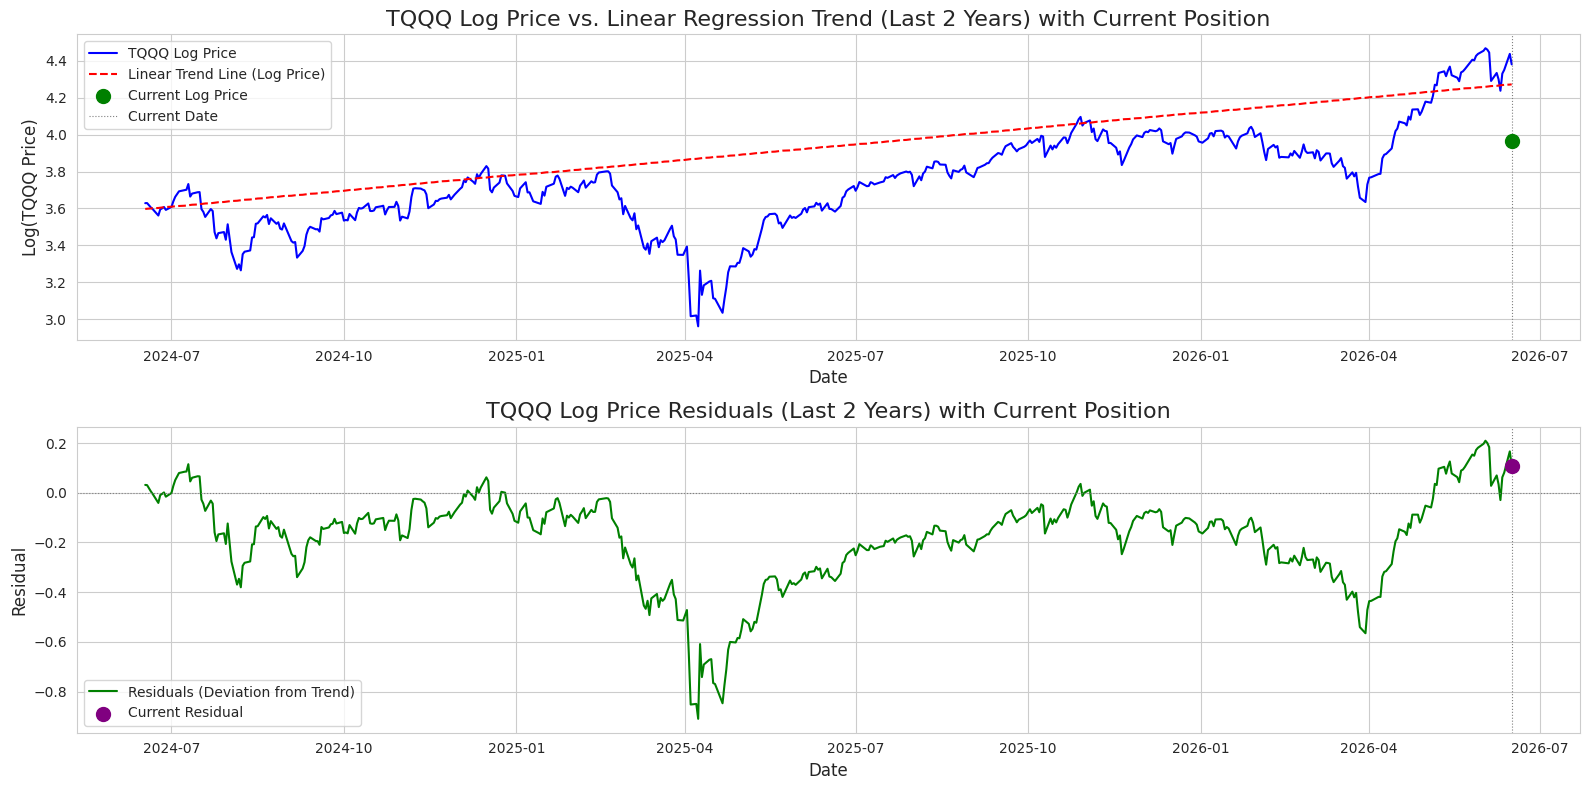

In [93]:
# Plot TQQQ log price, trend, and residuals with current position highlighted
sns.set_style('whitegrid')
plt.figure(figsize=(16, 8))

# Define the plot range for the last two years, ending at the current date
plot_end_date = current_date
plot_start_date = plot_end_date - pd.DateOffset(years=2)

# Filter the current_analysis_df for the plotting range
# This dataframe already contains log price, trend line and residuals for the full updated history
plot_df = current_analysis_df.loc[plot_start_date:plot_end_date]

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(plot_df.index, plot_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(plot_df.index, plot_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')

# Highlight current log price
plt.scatter(current_date, current_log_price, color='green', s=100, zorder=5, label='Current Log Price')
plt.axvline(current_date, color='gray', linestyle=':', linewidth=0.8, label='Current Date')

plt.title('TQQQ Log Price vs. Linear Regression Trend (Last 2 Years) with Current Position', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(plot_df.index, plot_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)

# Highlight current residual
plt.scatter(current_date, current_residual, color='purple', s=100, zorder=5, label='Current Residual')
plt.axvline(current_date, color='gray', linestyle=':', linewidth=0.8)

plt.title('TQQQ Log Price Residuals (Last 2 Years) with Current Position', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()